In [26]:
from getpass import getpass
from pathlib import Path
from datetime import datetime
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

from IPython.display import display, HTML

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

database_host = (
    input(
        "MySQL Host [localhost]: "
    ).strip()
    or "localhost"
)

database_port_text = input(
    "MySQL Port [3306]: "
).strip()

database_port = (
    int(database_port_text)
    if database_port_text
    else 3306
)

database_user = (
    input(
        "MySQL User [root]: "
    ).strip()
    or "root"
)

database_name = (
    input(
        "Database Name [SchoolPulsePortfolio]: "
    ).strip()
    or "SchoolPulsePortfolio"
)

database_password = None

write_results_to_database = True

analysis_periods = pd.DataFrame(
    [
        {
            "month_name": "January",
            "month_number": 1,
            "month_start": "2026-01-01",
            "month_end": "2026-01-31",
        },
        {
            "month_name": "February",
            "month_number": 2,
            "month_start": "2026-02-01",
            "month_end": "2026-02-28",
        },
        {
            "month_name": "March",
            "month_number": 3,
            "month_start": "2026-03-01",
            "month_end": "2026-03-31",
        },
        {
            "month_name": "April",
            "month_number": 4,
            "month_start": "2026-04-01",
            "month_end": "2026-04-30",
        },
    ]
)

analysis_periods["month_start"] = pd.to_datetime(
    analysis_periods["month_start"]
)

analysis_periods["month_end"] = pd.to_datetime(
    analysis_periods["month_end"]
)

high_score_threshold = 50
medium_score_threshold = 60
high_attendance_threshold = 70
medium_attendance_threshold = 85
high_failed_subject_threshold = 2
medium_failed_subject_threshold = 1

subject_high_score_threshold = 40
subject_medium_score_threshold = 50
subject_high_gap_threshold = -15

attendance_points = {
    "Present": 1.0,
    "Late": 0.5,
    "Absent": 0.0,
    "Excused": 0.0,
}

expected_source_counts = {
    "AcademicYear": 1,
    "Term": 1,
    "ClassLevel": 6,
    "AcademicStream": 3,
    "SchoolClass": 18,
    "Student": 216,
    "Teacher": 45,
    "SchoolSubject": 35,
    "StudentEnrollment": 216,
    "ClassSubject": 236,
    "TeacherAssignment": 236,
    "AttendanceRecord": 13608,
    "AssessmentType": 4,
    "Assessment": 944,
    "ScoreRecord": 11328,
    "RecognitionAward": 54,
}

export_directory = Path.cwd() / "SchoolPulse Portfolio Outputs"
export_directory.mkdir(parents=True, exist_ok=True)

print("Configuration Ready")

MySQL Host [localhost]:  
MySQL Port [3306]:  
MySQL User [root]:  
Database Name [SchoolPulsePortfolio]:  


Configuration Ready


In [27]:
def pascal_to_snake(value):
    first_pass = re.sub(
        r"(.)([A-Z][a-z]+)",
        r"\1_\2",
        value,
    )

    second_pass = re.sub(
        r"([a-z0-9])([A-Z])",
        r"\1_\2",
        first_pass,
    )

    return second_pass.lower()


def professional_label(value):
    acronym_map = {
        "id": "ID",
        "ca": "CA",
        "bi": "BI",
        "sql": "SQL",
        "api": "API",
    }

    words = pascal_to_snake(
        str(value)
    ).replace("-", " ").split("_")
    formatted_words = []

    for word in words:
        lower_word = word.lower()

        if lower_word in acronym_map:
            formatted_words.append(acronym_map[lower_word])
        else:
            formatted_words.append(word.capitalize())

    return " ".join(formatted_words)


def professional_frame(dataframe):
    result = dataframe.copy()

    column_labels = {
        "academic_stream": "Academic Group",
    }

    result.columns = [
        column_labels.get(
            column,
            professional_label(column),
        )
        for column in result.columns
    ]

    return result


def show_table(title, dataframe, rows=20):
    display(
        HTML(
            f"<h3>{title}</h3>"
        )
    )

    display(
        professional_frame(
            dataframe.head(rows)
        )
    )


def safe_records(dataframe):
    safe_dataframe = dataframe.astype(object).where(
        pd.notna(dataframe),
        None,
    )

    records = []

    for row in safe_dataframe.itertuples(
        index=False,
        name=None,
    ):
        safe_row = []

        for value in row:
            if isinstance(value, np.generic):
                value = value.item()

            if isinstance(value, pd.Timestamp):
                value = value.to_pydatetime()

            safe_row.append(value)

        records.append(tuple(safe_row))

    return records


quality_checks = []


def add_quality_check(
    check_name,
    actual_value,
    expected_value,
    passed,
):
    quality_checks.append(
        {
            "check_name": check_name,
            "actual_value": actual_value,
            "expected_value": expected_value,
            "validation_status": (
                "PASS"
                if passed
                else "CHECK"
            ),
        }
    )


print("Utility Functions Ready")

Utility Functions Ready


In [28]:
connection = None

while connection is None:
    database_password = getpass(
        "Enter MySQL Password For "
        + database_user
        + ": "
    )

    try:
        connection = mysql.connector.connect(
            host=database_host,
            port=database_port,
            user=database_user,
            password=database_password,
            database=database_name,
            connection_timeout=10,
        )

    except mysql.connector.Error as error:
        if error.errno == 1045:
            print(
                "Login Was Not Accepted. "
                "Enter The Same MySQL Username And Password "
                "Used In MySQL Workbench."
            )

            connection = None
            continue

        if error.errno == 1049:
            raise RuntimeError(
                "The Database "
                + database_name
                + " Was Not Found. "
                "Run The Professional SQL Script First."
            ) from error

        if error.errno in {
            2003,
            2005,
        }:
            raise RuntimeError(
                "MySQL Could Not Be Reached At "
                + database_host
                + ":"
                + str(
                    database_port
                )
                + ". Confirm That The MySQL Server Is Running."
            ) from error

        raise

connection_test_cursor = connection.cursor()

try:
    connection_test_cursor.execute(
        "SELECT DATABASE()"
    )

    connected_database = (
        connection_test_cursor.fetchone()[0]
    )

finally:
    connection_test_cursor.close()


def read_query(query, parameters=None):
    cursor = connection.cursor(
        dictionary=True
    )

    try:
        cursor.execute(
            query,
            parameters or (),
        )

        rows = cursor.fetchall()
        dataframe = pd.DataFrame(rows)

        if not dataframe.empty:
            dataframe.columns = [
                pascal_to_snake(column)
                for column in dataframe.columns
            ]

        return dataframe

    finally:
        cursor.close()


def read_table(table_name):
    approved_tables = (
        set(
            expected_source_counts
        )
        | {
            "StudentMonthlySummary",
            "StudentRiskProfile",
            "StudentSubjectRisk",
        }
    )

    if table_name not in approved_tables:
        raise ValueError(
            "Table Is Not Approved For This Pipeline"
        )

    return read_query(
        f"SELECT * FROM `{table_name}`"
    )


print(
    "Connected Successfully To "
    + connected_database
)

Enter MySQL Password For root:  ········


Connected Successfully To schoolpulseportfolio


In [29]:
source_tables = {
    table_name: read_table(table_name)
    for table_name in expected_source_counts
}

academic_year = source_tables["AcademicYear"]
term = source_tables["Term"]
class_level = source_tables["ClassLevel"]
academic_stream = source_tables["AcademicStream"]
school_class = source_tables["SchoolClass"]
student = source_tables["Student"]
teacher = source_tables["Teacher"]
school_subject = source_tables["SchoolSubject"]
student_enrollment = source_tables["StudentEnrollment"]
class_subject = source_tables["ClassSubject"]
teacher_assignment = source_tables["TeacherAssignment"]
attendance_record = source_tables["AttendanceRecord"]
assessment_type = source_tables["AssessmentType"]
assessment = source_tables["Assessment"]
score_record = source_tables["ScoreRecord"]
recognition_award = source_tables["RecognitionAward"]

for table_name, expected_count in expected_source_counts.items():
    actual_count = len(source_tables[table_name])

    add_quality_check(
        professional_label(table_name) + " Row Count",
        actual_count,
        expected_count,
        actual_count == expected_count,
    )

source_count_report = pd.DataFrame(quality_checks)

show_table(
    "Source Table Validation",
    source_count_report,
    rows=len(source_count_report),
)

if not (
    source_count_report["validation_status"] == "PASS"
).all():
    raise ValueError(
        "Source Table Count Validation Failed"
    )

,Check Name,Actual Value,Expected Value,Validation Status
0,Academic Year Row Count,1,1,PASS
1,Term Row Count,1,1,PASS
2,Class Level Row Count,6,6,PASS
3,Academic Stream Row Count,3,3,PASS
4,School Class Row Count,18,18,PASS
5,Student Row Count,216,216,PASS
6,Teacher Row Count,45,45,PASS
7,School Subject Row Count,35,35,PASS
8,Student Enrollment Row Count,216,216,PASS
9,Class Subject Row Count,236,236,PASS


In [30]:
date_columns = {
    "academic_year": (
        academic_year,
        [
            "start_date",
            "end_date",
        ],
    ),
    "term": (
        term,
        [
            "start_date",
            "end_date",
        ],
    ),
    "student": (
        student,
        [
            "date_of_birth",
            "admission_date",
        ],
    ),
    "student_enrollment": (
        student_enrollment,
        [
            "enrollment_date",
        ],
    ),
    "attendance_record": (
        attendance_record,
        [
            "attendance_date",
        ],
    ),
    "assessment": (
        assessment,
        [
            "assessment_date",
        ],
    ),
}

for table_name, (
    dataframe,
    columns,
) in date_columns.items():
    for column in columns:
        dataframe[column] = pd.to_datetime(
            dataframe[column],
            errors="coerce",
        )

        invalid_count = int(
            dataframe[column].isna().sum()
        )

        add_quality_check(
            professional_label(table_name)
            + " "
            + professional_label(column),
            invalid_count,
            0,
            invalid_count == 0,
        )

numeric_columns = {
    "assessment_type": (
        assessment_type,
        [
            "default_weight",
        ],
    ),
    "assessment": (
        assessment,
        [
            "max_score",
        ],
    ),
    "score_record": (
        score_record,
        [
            "score_obtained",
            "score_percentage",
        ],
    ),
}

for table_name, (
    dataframe,
    columns,
) in numeric_columns.items():
    for column in columns:
        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="coerce",
        )

        invalid_count = int(
            dataframe[column].isna().sum()
        )

        add_quality_check(
            professional_label(table_name)
            + " "
            + professional_label(column),
            invalid_count,
            0,
            invalid_count == 0,
        )

print("Data Types Prepared")

Data Types Prepared


In [31]:
primary_key_checks = {
    "Academic Year ID": (
        academic_year,
        "academic_year_id",
    ),
    "Term ID": (
        term,
        "term_id",
    ),
    "Class Level ID": (
        class_level,
        "class_level_id",
    ),
    "Academic Stream ID": (
        academic_stream,
        "stream_id",
    ),
    "Class ID": (
        school_class,
        "class_id",
    ),
    "Student ID": (
        student,
        "student_id",
    ),
    "Teacher ID": (
        teacher,
        "teacher_id",
    ),
    "Subject ID": (
        school_subject,
        "subject_id",
    ),
    "Enrollment ID": (
        student_enrollment,
        "enrollment_id",
    ),
    "Class Subject ID": (
        class_subject,
        "class_subject_id",
    ),
    "Teacher Assignment ID": (
        teacher_assignment,
        "teacher_assignment_id",
    ),
    "Attendance ID": (
        attendance_record,
        "attendance_id",
    ),
    "Assessment Type ID": (
        assessment_type,
        "assessment_type_id",
    ),
    "Assessment ID": (
        assessment,
        "assessment_id",
    ),
    "Score ID": (
        score_record,
        "score_id",
    ),
    "Award ID": (
        recognition_award,
        "award_id",
    ),
}

for check_name, (
    dataframe,
    column,
) in primary_key_checks.items():
    duplicate_count = int(
        dataframe[column].duplicated().sum()
    )

    missing_count = int(
        dataframe[column].isna().sum()
    )

    add_quality_check(
        "Duplicate " + check_name + " Records",
        duplicate_count,
        0,
        duplicate_count == 0,
    )

    add_quality_check(
        "Missing " + check_name + " Records",
        missing_count,
        0,
        missing_count == 0,
    )

composite_key_checks = {
    "Duplicate Student Term Enrollments": (
        student_enrollment,
        [
            "student_id",
            "term_id",
        ],
    ),
    "Duplicate Class Subject Assignments": (
        class_subject,
        [
            "class_id",
            "subject_id",
            "term_id",
        ],
    ),
    "Duplicate Teacher Assignments": (
        teacher_assignment,
        [
            "teacher_id",
            "class_subject_id",
            "term_id",
        ],
    ),
    "Duplicate Student Attendance Dates": (
        attendance_record,
        [
            "enrollment_id",
            "attendance_date",
        ],
    ),
    "Duplicate Class Subject Assessment Types": (
        assessment,
        [
            "class_subject_id",
            "assessment_type_id",
        ],
    ),
    "Duplicate Student Assessment Scores": (
        score_record,
        [
            "assessment_id",
            "enrollment_id",
        ],
    ),
}

for check_name, (
    dataframe,
    columns,
) in composite_key_checks.items():
    duplicate_count = int(
        dataframe.duplicated(
            subset=columns
        ).sum()
    )

    add_quality_check(
        check_name,
        duplicate_count,
        0,
        duplicate_count == 0,
    )

invalid_score_count = len(
    score_record[
        (score_record["score_percentage"] < 0)
        | (score_record["score_percentage"] > 100)
    ]
)

add_quality_check(
    "Score Percentages Outside Valid Range",
    invalid_score_count,
    0,
    invalid_score_count == 0,
)

weight_total = float(
    assessment_type["default_weight"].sum()
)

add_quality_check(
    "Assessment Weight Total",
    round(weight_total, 2),
    100,
    np.isclose(
        weight_total,
        100,
        atol=0.01,
    ),
)

print("Uniqueness And Range Checks Completed")

Uniqueness And Range Checks Completed


In [32]:
relationship_checks = {
    "Enrollment Student Relationships": (
        student_enrollment["student_id"].isin(
            student["student_id"]
        )
    ),
    "Enrollment Class Relationships": (
        student_enrollment["class_id"].isin(
            school_class["class_id"]
        )
    ),
    "Enrollment Term Relationships": (
        student_enrollment["term_id"].isin(
            term["term_id"]
        )
    ),
    "Class Level Relationships": (
        school_class["class_level_id"].isin(
            class_level["class_level_id"]
        )
    ),
    "Class Stream Relationships": (
        school_class["stream_id"].isna()
        | school_class["stream_id"].isin(
            academic_stream["stream_id"]
        )
    ),
    "Class Subject Class Relationships": (
        class_subject["class_id"].isin(
            school_class["class_id"]
        )
    ),
    "Class Subject Subject Relationships": (
        class_subject["subject_id"].isin(
            school_subject["subject_id"]
        )
    ),
    "Teacher Assignment Teacher Relationships": (
        teacher_assignment["teacher_id"].isin(
            teacher["teacher_id"]
        )
    ),
    "Teacher Assignment Subject Relationships": (
        teacher_assignment["class_subject_id"].isin(
            class_subject["class_subject_id"]
        )
    ),
    "Attendance Enrollment Relationships": (
        attendance_record["enrollment_id"].isin(
            student_enrollment["enrollment_id"]
        )
    ),
    "Assessment Type Relationships": (
        assessment["assessment_type_id"].isin(
            assessment_type["assessment_type_id"]
        )
    ),
    "Assessment Subject Relationships": (
        assessment["class_subject_id"].isin(
            class_subject["class_subject_id"]
        )
    ),
    "Score Assessment Relationships": (
        score_record["assessment_id"].isin(
            assessment["assessment_id"]
        )
    ),
    "Score Enrollment Relationships": (
        score_record["enrollment_id"].isin(
            student_enrollment["enrollment_id"]
        )
    ),
}

for check_name, valid_mask in relationship_checks.items():
    invalid_count = int(
        (~valid_mask).sum()
    )

    add_quality_check(
        check_name,
        invalid_count,
        0,
        invalid_count == 0,
    )

print("Relationship Checks Completed")

Relationship Checks Completed


In [33]:
class_details = (
    school_class.merge(
        class_level[
            [
                "class_level_id",
                "level_name",
                "school_section",
                "level_order",
            ]
        ],
        on="class_level_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        academic_stream[
            [
                "stream_id",
                "stream_name",
            ]
        ],
        on="stream_id",
        how="left",
        validate="many_to_one",
    )
)

class_details["academic_stream"] = (
    class_details["stream_name"]
    .fillna("Junior Secondary")
)

enrollment_details = (
    student_enrollment.merge(
        student,
        on="student_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        class_details,
        on="class_id",
        how="left",
        validate="many_to_one",
    )
)

enrollment_details["student_name"] = (
    enrollment_details["first_name"]
    + " "
    + enrollment_details["last_name"]
)

active_enrollments = enrollment_details[
    enrollment_details["enrollment_status"] == "Active"
].copy()

class_subject_counts = (
    class_subject.groupby("class_id")
    .agg(
        assigned_subjects=(
            "class_subject_id",
            "nunique",
        )
    )
    .reset_index()
)

class_student_counts = (
    active_enrollments.groupby("class_id")
    .agg(
        students=(
            "student_id",
            "nunique",
        )
    )
    .reset_index()
)

school_structure = (
    class_details.merge(
        class_subject_counts,
        on="class_id",
        how="left",
    )
    .merge(
        class_student_counts,
        on="class_id",
        how="left",
    )
    .sort_values(
        [
            "level_order",
            "class_name",
        ]
    )
    [
        [
            "class_name",
            "level_name",
            "class_section",
            "academic_stream",
            "students",
            "assigned_subjects",
        ]
    ]
    .reset_index(drop=True)
)

show_table(
    "School Structure",
    school_structure,
    rows=len(school_structure),
)

junior_subject_expectations = {
    "JSS1": 18,
    "JSS2": 17,
    "JSS3": 14,
}

for level_name, expected_subjects in junior_subject_expectations.items():
    matching_rows = school_structure[
        school_structure["level_name"] == level_name
    ]

    passed = (
        not matching_rows.empty
        and (
            matching_rows["assigned_subjects"]
            == expected_subjects
        ).all()
    )

    add_quality_check(
        level_name + " Subjects Per Class",
        (
            ", ".join(
                matching_rows[
                    "assigned_subjects"
                ]
                .astype(int)
                .astype(str)
                .tolist()
            )
        ),
        expected_subjects,
        passed,
    )

students_per_class_passed = (
    school_structure["students"] == 12
).all()

add_quality_check(
    "Students Per Class",
    (
        ", ".join(
            school_structure["students"]
            .astype(int)
            .astype(str)
            .tolist()
        )
    ),
    12,
    students_per_class_passed,
)

print("School Structure Validation Completed")

,Class Name,Level Name,Class Section,Academic Group,Students,Assigned Subjects
0,JSS1A,JSS1,Junior,Junior Secondary,12,18
1,JSS1B,JSS1,Junior,Junior Secondary,12,18
2,JSS2A,JSS2,Junior,Junior Secondary,12,17
3,JSS2B,JSS2,Junior,Junior Secondary,12,17
4,JSS3A,JSS3,Junior,Junior Secondary,12,14
5,JSS3B,JSS3,Junior,Junior Secondary,12,14
6,SS1A,SS1,Senior,Science,12,12
7,SS1B,SS1,Senior,Science,12,12
8,SS1C,SS1,Senior,Commercial,12,11
9,SS1D,SS1,Senior,Arts,12,11


School Structure Validation Completed


In [34]:
assessment_details = (
    assessment.merge(
        assessment_type[
            [
                "assessment_type_id",
                "type_name",
                "default_weight",
            ]
        ],
        on="assessment_type_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        class_subject[
            [
                "class_subject_id",
                "class_id",
                "subject_id",
                "term_id",
            ]
        ],
        on="class_subject_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        school_subject[
            [
                "subject_id",
                "subject_name",
                "subject_category",
            ]
        ],
        on="subject_id",
        how="left",
        validate="many_to_one",
    )
)

score_details = (
    score_record.merge(
        assessment_details,
        on="assessment_id",
        how="left",
        validate="many_to_one",
    )
)

score_details["score_percentage"] = pd.to_numeric(
    score_details["score_percentage"],
    errors="coerce",
)

score_details["default_weight"] = pd.to_numeric(
    score_details["default_weight"],
    errors="coerce",
)

score_details["assessment_date"] = pd.to_datetime(
    score_details["assessment_date"],
    errors="coerce",
)

score_count_by_assessment = (
    score_details.groupby("assessment_id")
    .agg(
        students_scored=(
            "enrollment_id",
            "nunique",
        )
    )
    .reset_index()
)

invalid_assessment_score_counts = len(
    score_count_by_assessment[
        score_count_by_assessment[
            "students_scored"
        ] != 12
    ]
)

add_quality_check(
    "Assessments Without Twelve Student Scores",
    invalid_assessment_score_counts,
    0,
    invalid_assessment_score_counts == 0,
)

expected_student_subject_rows = int(
    school_structure.eval(
        "students * assigned_subjects"
    ).sum()
)

add_quality_check(
    "Expected Student Subject Rows Per Month",
    expected_student_subject_rows,
    2832,
    expected_student_subject_rows == 2832,
)

print("Assessment And Score Data Prepared")

Assessment And Score Data Prepared


In [35]:
attendance_analysis = attendance_record.copy()

attendance_analysis["month_name"] = (
    attendance_analysis["attendance_date"]
    .dt.month_name()
)

attendance_analysis = attendance_analysis[
    attendance_analysis["month_name"].isin(
        analysis_periods["month_name"]
    )
].copy()

attendance_analysis["attendance_points"] = (
    attendance_analysis["attendance_status"]
    .map(attendance_points)
)

attendance_analysis["counted_day"] = np.where(
    attendance_analysis["attendance_status"]
    == "Excused",
    0,
    1,
)

unknown_attendance_statuses = int(
    attendance_analysis[
        "attendance_points"
    ].isna().sum()
)

add_quality_check(
    "Unknown Attendance Status Records",
    unknown_attendance_statuses,
    0,
    unknown_attendance_statuses == 0,
)

monthly_attendance = (
    attendance_analysis.groupby(
        [
            "enrollment_id",
            "month_name",
        ],
        as_index=False,
    )
    .agg(
        attendance_points=(
            "attendance_points",
            "sum",
        ),
        counted_days=(
            "counted_day",
            "sum",
        ),
        attendance_records=(
            "attendance_id",
            "count",
        ),
        present_days=(
            "attendance_status",
            lambda values: int(
                (values == "Present").sum()
            ),
        ),
        late_days=(
            "attendance_status",
            lambda values: int(
                (values == "Late").sum()
            ),
        ),
        absent_days=(
            "attendance_status",
            lambda values: int(
                (values == "Absent").sum()
            ),
        ),
        excused_days=(
            "attendance_status",
            lambda values: int(
                (values == "Excused").sum()
            ),
        ),
    )
)

monthly_attendance["attendance_percentage"] = (
    monthly_attendance["attendance_points"]
    / monthly_attendance["counted_days"]
    .replace(0, np.nan)
    * 100
).round(2)

month_number_map = dict(
    zip(
        analysis_periods["month_name"],
        analysis_periods["month_number"],
    )
)

monthly_attendance["month_number"] = (
    monthly_attendance["month_name"]
    .map(month_number_map)
)

attendance_month_validation = (
    monthly_attendance.groupby(
        [
            "month_number",
            "month_name",
        ]
    )
    .agg(
        students=(
            "enrollment_id",
            "nunique",
        ),
        minimum_attendance_records=(
            "attendance_records",
            "min",
        ),
        maximum_attendance_records=(
            "attendance_records",
            "max",
        ),
    )
    .reset_index()
    .sort_values("month_number")
)

show_table(
    "Monthly Attendance Coverage",
    attendance_month_validation,
    rows=len(attendance_month_validation),
)

for row in attendance_month_validation.itertuples(
    index=False
):
    add_quality_check(
        row.month_name + " Attendance Coverage",
        row.students,
        216,
        row.students == 216,
    )

print("Monthly Attendance Calculated")

,Month Number,Month Name,Students,Minimum Attendance Records,Maximum Attendance Records
0,1,January,216,15,15
1,2,February,216,20,20
2,3,March,216,20,20
3,4,April,216,8,8


Monthly Attendance Calculated


In [36]:
subject_month_frames = []
coverage_frames = []

for period in analysis_periods.itertuples(
    index=False
):
    completed_scores = score_details[
        score_details["assessment_date"]
        <= period.month_end
    ].copy()

    category_results = (
        completed_scores.groupby(
            [
                "enrollment_id",
                "class_subject_id",
                "class_id",
                "subject_id",
                "subject_name",
                "subject_category",
                "assessment_type_id",
                "type_name",
                "default_weight",
            ],
            as_index=False,
        )
        .agg(
            category_average=(
                "score_percentage",
                "mean",
            ),
            assessment_count=(
                "assessment_id",
                "nunique",
            ),
        )
    )

    category_results["weighted_points"] = (
        category_results[
            "category_average"
        ]
        * category_results[
            "default_weight"
        ]
        / 100
    )

    subject_results = (
        category_results.groupby(
            [
                "enrollment_id",
                "class_subject_id",
                "class_id",
                "subject_id",
                "subject_name",
                "subject_category",
            ],
            as_index=False,
        )
        .agg(
            weighted_points=(
                "weighted_points",
                "sum",
            ),
            completed_weight=(
                "default_weight",
                "sum",
            ),
            completed_categories=(
                "assessment_type_id",
                "nunique",
            ),
        )
    )

    subject_results["subject_average"] = (
        subject_results["weighted_points"]
        / subject_results["completed_weight"]
        * 100
    ).round(2)

    expected_weight = float(
        completed_scores[
            [
                "assessment_type_id",
                "default_weight",
            ]
        ]
        .drop_duplicates(
            subset=[
                "assessment_type_id",
            ]
        )["default_weight"]
        .sum()
    )

    expected_categories = int(
        completed_scores[
            "assessment_type_id"
        ].nunique()
    )

    subject_results["month_name"] = (
        period.month_name
    )

    subject_results["month_number"] = (
        period.month_number
    )

    subject_results["expected_weight"] = (
        expected_weight
    )

    subject_results["coverage_difference"] = (
        subject_results["completed_weight"]
        - expected_weight
    ).round(2)

    coverage_frames.append(
        subject_results[
            [
                "enrollment_id",
                "class_subject_id",
                "month_name",
                "completed_weight",
                "expected_weight",
                "coverage_difference",
            ]
        ]
    )

    subject_month_frames.append(
        subject_results
    )

student_subject_analysis = pd.concat(
    subject_month_frames,
    ignore_index=True,
)

assessment_coverage = pd.concat(
    coverage_frames,
    ignore_index=True,
)

expected_weight_by_month = {
    "January": 10,
    "February": 20,
    "March": 40,
    "April": 100,
}

coverage_summary = (
    assessment_coverage.groupby(
        "month_name"
    )
    .agg(
        minimum_completed_weight=(
            "completed_weight",
            "min",
        ),
        maximum_completed_weight=(
            "completed_weight",
            "max",
        ),
        coverage_failures=(
            "coverage_difference",
            lambda values: int(
                (~np.isclose(
                    values,
                    0,
                    atol=0.01,
                )).sum()
            ),
        ),
    )
    .reset_index()
)

coverage_summary["month_number"] = (
    coverage_summary["month_name"]
    .map(month_number_map)
)

coverage_summary = coverage_summary.sort_values(
    "month_number"
)

show_table(
    "Assessment Coverage",
    coverage_summary[
        [
            "month_name",
            "minimum_completed_weight",
            "maximum_completed_weight",
            "coverage_failures",
        ]
    ],
    rows=len(coverage_summary),
)

for row in coverage_summary.itertuples(
    index=False
):
    expected_weight = expected_weight_by_month[
        row.month_name
    ]

    passed = (
        np.isclose(
            row.minimum_completed_weight,
            expected_weight,
            atol=0.01,
        )
        and np.isclose(
            row.maximum_completed_weight,
            expected_weight,
            atol=0.01,
        )
        and row.coverage_failures == 0
    )

    add_quality_check(
        row.month_name
        + " Completed Assessment Weight",
        row.minimum_completed_weight,
        expected_weight,
        passed,
    )

add_quality_check(
    "Student Subject Analysis Rows",
    len(student_subject_analysis),
    11328,
    len(student_subject_analysis) == 11328,
)

print("Weighted Subject Performance Calculated")

,Month Name,Minimum Completed Weight,Maximum Completed Weight,Coverage Failures
2,January,10.0,10.0,0
1,February,20.0,20.0,0
3,March,40.0,40.0,0
0,April,100.0,100.0,0


Weighted Subject Performance Calculated


In [37]:
student_subject_analysis = (
    student_subject_analysis.merge(
        active_enrollments[
            [
                "enrollment_id",
                "student_id",
                "student_name",
                "gender",
                "class_id",
                "class_name",
                "level_name",
                "class_section",
                "academic_stream",
            ]
        ],
        on=[
            "enrollment_id",
            "class_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

student_monthly_scores = (
    student_subject_analysis.groupby(
        [
            "enrollment_id",
            "month_number",
            "month_name",
        ],
        as_index=False,
    )
    .agg(
        average_score=(
            "subject_average",
            "mean",
        ),
        subjects_assessed=(
            "class_subject_id",
            "nunique",
        ),
        subjects_failed=(
            "subject_average",
            lambda values: int(
                (values < 50).sum()
            ),
        ),
        average_completed_weight=(
            "completed_weight",
            "mean",
        ),
    )
)

student_monthly_scores[
    "average_score"
] = (
    student_monthly_scores[
        "average_score"
    ].round(2)
)

student_monthly_scores[
    "average_completed_weight"
] = (
    student_monthly_scores[
        "average_completed_weight"
    ].round(2)
)

student_monthly_analysis = (
    student_monthly_scores.merge(
        monthly_attendance,
        on=[
            "enrollment_id",
            "month_number",
            "month_name",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        active_enrollments[
            [
                "enrollment_id",
                "student_id",
                "student_name",
                "gender",
                "class_id",
                "class_name",
                "level_name",
                "class_section",
                "academic_stream",
            ]
        ],
        on="enrollment_id",
        how="left",
        validate="many_to_one",
    )
)

student_monthly_analysis = (
    student_monthly_analysis.sort_values(
        [
            "enrollment_id",
            "month_number",
        ]
    )
    .reset_index(drop=True)
)

student_monthly_analysis[
    "performance_change"
] = (
    student_monthly_analysis.groupby(
        "enrollment_id"
    )["average_score"]
    .diff()
    .round(2)
)

student_monthly_analysis[
    "performance_trend"
] = np.select(
    [
        student_monthly_analysis[
            "performance_change"
        ] >= 2,
        student_monthly_analysis[
            "performance_change"
        ] <= -2,
    ],
    [
        "Improving",
        "Declining",
    ],
    default="Stable",
)

student_monthly_analysis.loc[
    student_monthly_analysis[
        "performance_change"
    ].isna(),
    "performance_trend",
] = "Baseline"

print("Monthly Student Performance Calculated")

Monthly Student Performance Calculated


In [38]:
def assign_overall_risk(row):
    if (
        row["average_score"]
        < high_score_threshold
        or row["attendance_percentage"]
        < high_attendance_threshold
        or row["subjects_failed"]
        >= high_failed_subject_threshold
    ):
        return "High"

    if (
        row["average_score"]
        < medium_score_threshold
        or row["attendance_percentage"]
        < medium_attendance_threshold
        or row["subjects_failed"]
        >= medium_failed_subject_threshold
    ):
        return "Medium"

    return "Low"


def create_overall_reason(row):
    reasons = []

    if row["average_score"] < 50:
        reasons.append(
            "Average Score Is Below 50 Percent"
        )
    elif row["average_score"] < 60:
        reasons.append(
            "Average Score Is Below 60 Percent"
        )

    if row["attendance_percentage"] < 70:
        reasons.append(
            "Attendance Is Below 70 Percent"
        )
    elif row["attendance_percentage"] < 85:
        reasons.append(
            "Attendance Is Below 85 Percent"
        )

    if row["subjects_failed"] >= 2:
        reasons.append(
            "Student Is Below 50 Percent In "
            + str(
                int(
                    row["subjects_failed"]
                )
            )
            + " Subjects"
        )
    elif row["subjects_failed"] == 1:
        reasons.append(
            "Student Is Below 50 Percent In 1 Subject"
        )

    if not reasons:
        return (
            "Student Performance Is Within "
            "The Acceptable Range"
        )

    return "; ".join(reasons)


def create_overall_action(risk_level):
    if risk_level == "High":
        return (
            "Immediate Teacher Intervention "
            "Parent Contact And Targeted Support"
        )

    if risk_level == "Medium":
        return (
            "Close Monitoring Extra Practice "
            "And Monthly Progress Review"
        )

    return (
        "Continue Normal Monitoring "
        "And Encourage Current Performance"
    )


def calculate_risk_score(row):
    academic_risk = 100 - row["average_score"]
    attendance_risk = (
        100 - row["attendance_percentage"]
    )
    failed_subject_risk = min(
        row["subjects_failed"] * 25,
        100,
    )

    result = (
        academic_risk * 0.50
        + attendance_risk * 0.30
        + failed_subject_risk * 0.20
    )

    return round(
        float(
            np.clip(
                result,
                0,
                100,
            )
        ),
        2,
    )


student_monthly_analysis["risk_level"] = (
    student_monthly_analysis.apply(
        assign_overall_risk,
        axis=1,
    )
)

student_monthly_analysis["risk_score"] = (
    student_monthly_analysis.apply(
        calculate_risk_score,
        axis=1,
    )
)

student_monthly_analysis["risk_reason"] = (
    student_monthly_analysis.apply(
        create_overall_reason,
        axis=1,
    )
)

student_monthly_analysis[
    "recommended_action"
] = (
    student_monthly_analysis[
        "risk_level"
    ].map(
        create_overall_action
    )
)

student_monthly_analysis[
    "summary_status"
] = "Calculated"

student_monthly_analysis = (
    student_monthly_analysis.sort_values(
        [
            "month_number",
            "enrollment_id",
        ]
    )
    .reset_index(drop=True)
)

student_monthly_analysis[
    "monthly_summary_id"
] = [
    "MS" + str(number).zfill(5)
    for number in range(
        1,
        len(
            student_monthly_analysis
        )
        + 1,
    )
]

student_monthly_analysis[
    "risk_profile_id"
] = [
    "RP" + str(number).zfill(5)
    for number in range(
        1,
        len(
            student_monthly_analysis
        )
        + 1,
    )
]

print("Overall Student Risk Calculated")

Overall Student Risk Calculated


In [39]:
class_subject_month_average = (
    student_subject_analysis.groupby(
        [
            "month_number",
            "month_name",
            "class_subject_id",
        ],
        as_index=False,
    )
    .agg(
        class_subject_average=(
            "subject_average",
            "mean",
        )
    )
)

class_subject_month_average[
    "class_subject_average"
] = (
    class_subject_month_average[
        "class_subject_average"
    ].round(2)
)

student_subject_risk_analysis = (
    student_subject_analysis.merge(
        class_subject_month_average,
        on=[
            "month_number",
            "month_name",
            "class_subject_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

student_subject_risk_analysis[
    "performance_gap"
] = (
    student_subject_risk_analysis[
        "subject_average"
    ]
    - student_subject_risk_analysis[
        "class_subject_average"
    ]
).round(2)


def assign_subject_risk(row):
    if (
        row["subject_average"]
        < subject_high_score_threshold
        or row["performance_gap"]
        <= subject_high_gap_threshold
    ):
        return "High"

    if (
        row["subject_average"]
        < subject_medium_score_threshold
        or row["performance_gap"] < 0
    ):
        return "Medium"

    return "Low"


def create_subject_reason(row):
    reasons = []

    if row["subject_average"] < 40:
        reasons.append(
            "Subject Average Is Below 40 Percent"
        )
    elif row["subject_average"] < 50:
        reasons.append(
            "Subject Average Is Below 50 Percent"
        )

    if row["performance_gap"] <= -15:
        reasons.append(
            "Student Is At Least 15 Percentage "
            "Points Below The Class Average"
        )
    elif row["performance_gap"] < 0:
        reasons.append(
            "Student Is Below The Class Average"
        )

    if not reasons:
        return (
            "Subject Performance Is Within "
            "The Acceptable Range"
        )

    return "; ".join(reasons)


def create_subject_action(risk_level):
    if risk_level == "High":
        return (
            "Immediate Subject Teacher Intervention "
            "And Remedial Support"
        )

    if risk_level == "Medium":
        return (
            "Provide Extra Practice "
            "And Review The Next Assessment"
        )

    return "Continue Normal Subject Monitoring"


student_subject_risk_analysis[
    "risk_level"
] = (
    student_subject_risk_analysis.apply(
        assign_subject_risk,
        axis=1,
    )
)

student_subject_risk_analysis[
    "risk_reason"
] = (
    student_subject_risk_analysis.apply(
        create_subject_reason,
        axis=1,
    )
)

student_subject_risk_analysis[
    "recommended_action"
] = (
    student_subject_risk_analysis[
        "risk_level"
    ].map(
        create_subject_action
    )
)

student_subject_risk_analysis = (
    student_subject_risk_analysis.merge(
        student_monthly_analysis[
            [
                "enrollment_id",
                "month_number",
                "monthly_summary_id",
            ]
        ],
        on=[
            "enrollment_id",
            "month_number",
        ],
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "month_number",
            "enrollment_id",
            "class_subject_id",
        ]
    )
    .reset_index(drop=True)
)

student_subject_risk_analysis[
    "subject_risk_id"
] = [
    "SR" + str(number).zfill(6)
    for number in range(
        1,
        len(
            student_subject_risk_analysis
        )
        + 1,
    )
]

print("Subject Risk Calculated")

Subject Risk Calculated


In [40]:
add_quality_check(
    "Monthly Student Analysis Rows",
    len(student_monthly_analysis),
    864,
    len(student_monthly_analysis) == 864,
)

add_quality_check(
    "Subject Risk Analysis Rows",
    len(student_subject_risk_analysis),
    11328,
    len(student_subject_risk_analysis) == 11328,
)

monthly_student_counts = (
    student_monthly_analysis.groupby(
        "month_name"
    )["enrollment_id"]
    .nunique()
)

for month_name in analysis_periods[
    "month_name"
]:
    student_count = int(
        monthly_student_counts.get(
            month_name,
            0,
        )
    )

    add_quality_check(
        month_name + " Student Count",
        student_count,
        216,
        student_count == 216,
    )

missing_monthly_values = int(
    student_monthly_analysis[
        [
            "attendance_percentage",
            "average_score",
            "subjects_failed",
            "risk_level",
        ]
    ]
    .isna()
    .any(axis=1)
    .sum()
)

add_quality_check(
    "Monthly Analysis Missing Values",
    missing_monthly_values,
    0,
    missing_monthly_values == 0,
)

missing_subject_values = int(
    student_subject_risk_analysis[
        [
            "subject_average",
            "class_subject_average",
            "performance_gap",
            "risk_level",
            "monthly_summary_id",
        ]
    ]
    .isna()
    .any(axis=1)
    .sum()
)

add_quality_check(
    "Subject Risk Missing Values",
    missing_subject_values,
    0,
    missing_subject_values == 0,
)

duplicate_monthly_keys = int(
    student_monthly_analysis.duplicated(
        subset=[
            "enrollment_id",
            "month_name",
        ]
    ).sum()
)

add_quality_check(
    "Duplicate Monthly Student Records",
    duplicate_monthly_keys,
    0,
    duplicate_monthly_keys == 0,
)

duplicate_subject_keys = int(
    student_subject_risk_analysis.duplicated(
        subset=[
            "monthly_summary_id",
            "class_subject_id",
        ]
    ).sum()
)

add_quality_check(
    "Duplicate Monthly Subject Risk Records",
    duplicate_subject_keys,
    0,
    duplicate_subject_keys == 0,
)

invalid_monthly_ranges = len(
    student_monthly_analysis[
        (
            student_monthly_analysis[
                "attendance_percentage"
            ] < 0
        )
        | (
            student_monthly_analysis[
                "attendance_percentage"
            ] > 100
        )
        | (
            student_monthly_analysis[
                "average_score"
            ] < 0
        )
        | (
            student_monthly_analysis[
                "average_score"
            ] > 100
        )
    ]
)

add_quality_check(
    "Monthly Values Outside Valid Range",
    invalid_monthly_ranges,
    0,
    invalid_monthly_ranges == 0,
)

quality_report = pd.DataFrame(
    quality_checks
)

show_table(
    "Complete Data Quality Report",
    quality_report,
    rows=len(quality_report),
)

failed_quality_checks = quality_report[
    quality_report[
        "validation_status"
    ] != "PASS"
]

if not failed_quality_checks.empty:
    raise ValueError(
        "One Or More Data Quality Checks Failed"
    )

print("All Data Quality Checks Passed")

,Check Name,Actual Value,Expected Value,Validation Status
0,Academic Year Row Count,1,1,PASS
1,Term Row Count,1,1,PASS
2,Class Level Row Count,6,6,PASS
3,Academic Stream Row Count,3,3,PASS
4,School Class Row Count,18,18,PASS
5,Student Row Count,216,216,PASS
6,Teacher Row Count,45,45,PASS
7,School Subject Row Count,35,35,PASS
8,Student Enrollment Row Count,216,216,PASS
9,Class Subject Row Count,236,236,PASS


All Data Quality Checks Passed


In [41]:
monthly_school_summary = (
    student_monthly_analysis.groupby(
        [
            "month_number",
            "month_name",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        ),
        average_academic_score=(
            "average_score",
            "mean",
        ),
        average_attendance=(
            "attendance_percentage",
            "mean",
        ),
        high_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "High").sum()
            ),
        ),
        medium_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "Medium").sum()
            ),
        ),
        low_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "Low").sum()
            ),
        ),
        students_failing_subjects=(
            "subjects_failed",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        attendance_concerns=(
            "attendance_percentage",
            lambda values: int(
                (values < 85).sum()
            ),
        ),
    )
    .sort_values("month_number")
)

monthly_school_summary[
    [
        "average_academic_score",
        "average_attendance",
    ]
] = (
    monthly_school_summary[
        [
            "average_academic_score",
            "average_attendance",
        ]
    ].round(2)
)

class_performance_summary = (
    student_monthly_analysis.groupby(
        [
            "month_number",
            "month_name",
            "class_name",
            "level_name",
            "academic_stream",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        ),
        average_score=(
            "average_score",
            "mean",
        ),
        average_attendance=(
            "attendance_percentage",
            "mean",
        ),
        high_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "High").sum()
            ),
        ),
        medium_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "Medium").sum()
            ),
        ),
    )
)

class_performance_summary[
    [
        "average_score",
        "average_attendance",
    ]
] = (
    class_performance_summary[
        [
            "average_score",
            "average_attendance",
        ]
    ].round(2)
)

stream_performance_summary = (
    student_monthly_analysis.groupby(
        [
            "month_number",
            "month_name",
            "academic_stream",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        ),
        average_score=(
            "average_score",
            "mean",
        ),
        average_attendance=(
            "attendance_percentage",
            "mean",
        ),
        high_risk_students=(
            "risk_level",
            lambda values: int(
                (values == "High").sum()
            ),
        ),
    )
)

stream_performance_summary[
    [
        "average_score",
        "average_attendance",
    ]
] = (
    stream_performance_summary[
        [
            "average_score",
            "average_attendance",
        ]
    ].round(2)
)

subject_performance_summary = (
    student_subject_risk_analysis.groupby(
        [
            "month_number",
            "month_name",
            "subject_name",
            "subject_category",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        ),
        average_subject_score=(
            "subject_average",
            "mean",
        ),
        high_risk_records=(
            "risk_level",
            lambda values: int(
                (values == "High").sum()
            ),
        ),
        medium_risk_records=(
            "risk_level",
            lambda values: int(
                (values == "Medium").sum()
            ),
        ),
    )
)

subject_performance_summary[
    "average_subject_score"
] = (
    subject_performance_summary[
        "average_subject_score"
    ].round(2)
)

gender_performance_summary = (
    student_monthly_analysis.groupby(
        [
            "month_number",
            "month_name",
            "gender",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        ),
        average_score=(
            "average_score",
            "mean",
        ),
        average_attendance=(
            "attendance_percentage",
            "mean",
        ),
    )
)

gender_performance_summary[
    [
        "average_score",
        "average_attendance",
    ]
] = (
    gender_performance_summary[
        [
            "average_score",
            "average_attendance",
        ]
    ].round(2)
)

show_table(
    "Monthly School Performance",
    monthly_school_summary,
    rows=len(monthly_school_summary),
)

,Month Number,Month Name,Students,Average Academic Score,Average Attendance,High Risk Students,Medium Risk Students,Low Risk Students,Students Failing Subjects,Attendance Concerns
0,1,January,216,69.87,81.25,60,54,102,49,108
1,2,February,216,68.63,81.92,59,48,109,47,100
2,3,March,216,66.86,80.97,59,61,96,48,114
3,4,April,216,64.51,80.28,80,55,81,70,110


In [42]:
risk_rank = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
}

risk_history = (
    student_monthly_analysis[
        [
            "student_id",
            "student_name",
            "class_name",
            "month_number",
            "month_name",
            "risk_level",
            "average_score",
            "attendance_percentage",
            "performance_change",
        ]
    ]
    .sort_values(
        [
            "student_id",
            "month_number",
        ]
    )
    .copy()
)

risk_history["previous_month"] = (
    risk_history.groupby(
        "student_id"
    )["month_name"]
    .shift()
)

risk_history["previous_risk_level"] = (
    risk_history.groupby(
        "student_id"
    )["risk_level"]
    .shift()
)

risk_history["previous_risk_rank"] = (
    risk_history[
        "previous_risk_level"
    ].map(risk_rank)
)

risk_history["current_risk_rank"] = (
    risk_history[
        "risk_level"
    ].map(risk_rank)
)

risk_history["risk_movement"] = np.select(
    [
        risk_history[
            "current_risk_rank"
        ]
        < risk_history[
            "previous_risk_rank"
        ],
        risk_history[
            "current_risk_rank"
        ]
        > risk_history[
            "previous_risk_rank"
        ],
    ],
    [
        "Improved",
        "Worsened",
    ],
    default="Unchanged",
)

risk_transitions = risk_history[
    risk_history[
        "previous_risk_level"
    ].notna()
].copy()

risk_transition_summary = (
    risk_transitions.groupby(
        [
            "previous_month",
            "month_name",
            "previous_risk_level",
            "risk_level",
            "risk_movement",
        ],
        as_index=False,
    )
    .agg(
        students=(
            "student_id",
            "nunique",
        )
    )
)

student_improvement_ranking = (
    student_monthly_analysis[
        student_monthly_analysis[
            "month_name"
        ] == "April"
    ]
    [
        [
            "student_id",
            "student_name",
            "class_name",
            "academic_stream",
            "average_score",
            "attendance_percentage",
            "performance_change",
            "performance_trend",
            "risk_level",
        ]
    ]
    .sort_values(
        "performance_change",
        ascending=False,
    )
    .reset_index(drop=True)
)

student_improvement_ranking[
    "performance_rank"
] = (
    np.arange(
        1,
        len(
            student_improvement_ranking
        )
        + 1,
    )
)

correlation_rows = []

for (
    month_number,
    month_name,
), group in student_monthly_analysis.groupby(
    [
        "month_number",
        "month_name",
    ]
):
    correlation_value = group[
        [
            "attendance_percentage",
            "average_score",
        ]
    ].corr().iloc[0, 1]

    correlation_rows.append(
        {
            "month_number": month_number,
            "month_name": month_name,
            "attendance_score_correlation": round(
                float(
                    correlation_value
                ),
                4,
            ),
        }
    )

correlation_summary = pd.DataFrame(
    correlation_rows
).sort_values("month_number")

show_table(
    "Risk Transition Summary",
    risk_transition_summary,
    rows=30,
)

show_table(
    "Attendance And Academic Correlation",
    correlation_summary,
    rows=len(correlation_summary),
)

,Previous Month,Month Name,Previous Risk Level,Risk Level,Risk Movement,Students
0,February,March,High,High,Unchanged,44
1,February,March,High,Low,Improved,4
2,February,March,High,Medium,Improved,11
3,February,March,Low,High,Worsened,4
4,February,March,Low,Low,Unchanged,75
5,February,March,Low,Medium,Worsened,30
6,February,March,Medium,High,Worsened,11
7,February,March,Medium,Low,Improved,17
8,February,March,Medium,Medium,Unchanged,20
9,January,February,High,High,Unchanged,45


,Month Number,Month Name,Attendance Score Correlation
0,1,January,0.5190
1,2,February,0.5352
2,3,March,0.5965
3,4,April,0.4655


In [43]:
intervention_queue = (
    student_monthly_analysis[
        student_monthly_analysis[
            "risk_level"
        ].isin(
            [
                "High",
                "Medium",
            ]
        )
    ]
    [
        [
            "monthly_summary_id",
            "student_id",
            "student_name",
            "class_name",
            "academic_stream",
            "month_number",
            "month_name",
            "attendance_percentage",
            "average_score",
            "subjects_failed",
            "risk_level",
            "risk_score",
            "risk_reason",
            "recommended_action",
        ]
    ]
    .sort_values(
        [
            "month_number",
            "risk_score",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

event_candidates = []

for row in student_monthly_analysis.itertuples(
    index=False
):
    month_end = analysis_periods.loc[
        analysis_periods[
            "month_name"
        ] == row.month_name,
        "month_end",
    ].iloc[0]

    if row.risk_level in {
        "High",
        "Medium",
    }:
        event_candidates.append(
            {
                "student_id": row.student_id,
                "event_type": (
                    row.risk_level
                    + " Risk Alert"
                ),
                "event_date": month_end,
                "risk_level": row.risk_level,
                "event_status": "Open",
                "message": (
                    row.student_name
                    + " Was Classified As "
                    + row.risk_level
                    + " Risk For "
                    + row.month_name
                ),
                "source": (
                    "Python Analytics Pipeline"
                ),
                "monthly_summary_id": (
                    row.monthly_summary_id
                ),
                "class_name": row.class_name,
            }
        )

    if row.attendance_percentage < 85:
        event_candidates.append(
            {
                "student_id": row.student_id,
                "event_type": (
                    "Attendance Concern"
                ),
                "event_date": month_end,
                "risk_level": row.risk_level,
                "event_status": "Open",
                "message": (
                    row.student_name
                    + " Recorded "
                    + str(
                        row.attendance_percentage
                    )
                    + " Percent Attendance In "
                    + row.month_name
                ),
                "source": (
                    "Python Analytics Pipeline"
                ),
                "monthly_summary_id": (
                    row.monthly_summary_id
                ),
                "class_name": row.class_name,
            }
        )

    if (
        row.risk_level == "Low"
        and pd.notna(
            row.performance_change
        )
        and row.performance_change >= 5
    ):
        event_candidates.append(
            {
                "student_id": row.student_id,
                "event_type": (
                    "Positive Performance Event"
                ),
                "event_date": month_end,
                "risk_level": row.risk_level,
                "event_status": "Completed",
                "message": (
                    row.student_name
                    + " Improved By "
                    + str(
                        row.performance_change
                    )
                    + " Percentage Points In "
                    + row.month_name
                ),
                "source": (
                    "Python Analytics Pipeline"
                ),
                "monthly_summary_id": (
                    row.monthly_summary_id
                ),
                "class_name": row.class_name,
            }
        )

dynamodb_event_candidates = pd.DataFrame(
    event_candidates
)

dynamodb_event_candidates = (
    dynamodb_event_candidates.sort_values(
        [
            "event_date",
            "student_id",
            "event_type",
        ]
    )
    .reset_index(drop=True)
)

dynamodb_event_candidates["event_id"] = [
    "EVT" + str(number).zfill(6)
    for number in range(
        1,
        len(
            dynamodb_event_candidates
        )
        + 1,
    )
]

dynamodb_event_candidates["event_key"] = (
    dynamodb_event_candidates[
        "event_date"
    ].dt.strftime(
        "%Y-%m-%dT17:00:00"
    )
    + "#"
    + dynamodb_event_candidates[
        "event_type"
    ]
    .str.upper()
    .str.replace(
        " ",
        "",
        regex=False,
    )
    + "#"
    + dynamodb_event_candidates[
        "event_id"
    ]
)

show_table(
    "Student Intervention Queue",
    intervention_queue,
    rows=20,
)

show_table(
    "DynamoDB Event Candidates",
    dynamodb_event_candidates,
    rows=20,
)

,Monthly Summary ID,Student ID,Student Name,Class Name,Academic Group,Month Number,Month Name,Attendance Percentage,Average Score,Subjects Failed,Risk Level,Risk Score,Risk Reason,Recommended Action
0,MS00016,STU0016,Stephen Uche,JSS1B,Junior Secondary,1,January,43.33,48.72,9,High,62.64,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
1,MS00116,STU0116,Philip Ndukwe,SS1D,Arts,1,January,46.43,47.96,7,High,62.09,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
2,MS00058,STU0058,Anita Olumide,JSS3A,Junior Secondary,1,January,46.67,51.75,6,High,60.12,Average Score Is Below 60 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
3,MS00134,STU0134,Daniel Adelaja,SS2B,Science,1,January,53.33,47.77,8,High,60.12,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
4,MS00145,STU0145,Henry Udoh,SS2C,Commercial,1,January,56.67,46.22,7,High,59.89,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
5,MS00140,STU0140,Isaac Danjuma,SS2B,Science,1,January,60.00,46.31,7,High,58.84,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
6,MS00005,STU0005,Olamide Asuquo,JSS1A,Junior Secondary,1,January,64.29,45.07,16,High,58.18,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
7,MS00117,STU0117,Grace Olaniyan,SS1D,Arts,1,January,63.33,46.31,6,High,57.85,Average Score Is Below 50 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
8,MS00032,STU0032,Adanna Akpan,JSS2A,Junior Secondary,1,January,53.57,53.22,8,High,57.32,Average Score Is Below 60 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...
9,MS00071,STU0071,Patience Ejiofor,JSS3B,Junior Secondary,1,January,56.67,51.62,4,High,57.19,Average Score Is Below 60 Percent; Attendance ...,Immediate Teacher Intervention Parent Contact ...


,Student ID,Event Type,Event Date,Risk Level,Event Status,Message,Source,Monthly Summary ID,Class Name,Event ID,Event Key
0,STU0004,Attendance Concern,2026-01-31,High,Open,Peace Oladimeji Recorded 60.71 Percent Attenda...,Python Analytics Pipeline,MS00004,JSS1A,EVT000001,2026-01-31T17:00:00#ATTENDANCECONCERN#EVT000001
1,STU0004,High Risk Alert,2026-01-31,High,Open,Peace Oladimeji Was Classified As High Risk Fo...,Python Analytics Pipeline,MS00004,JSS1A,EVT000002,2026-01-31T17:00:00#HIGHRISKALERT#EVT000002
2,STU0005,Attendance Concern,2026-01-31,High,Open,Olamide Asuquo Recorded 64.29 Percent Attendan...,Python Analytics Pipeline,MS00005,JSS1A,EVT000003,2026-01-31T17:00:00#ATTENDANCECONCERN#EVT000003
3,STU0005,High Risk Alert,2026-01-31,High,Open,Olamide Asuquo Was Classified As High Risk For...,Python Analytics Pipeline,MS00005,JSS1A,EVT000004,2026-01-31T17:00:00#HIGHRISKALERT#EVT000004
4,STU0006,High Risk Alert,2026-01-31,High,Open,Eunice Ezeh Was Classified As High Risk For Ja...,Python Analytics Pipeline,MS00006,JSS1A,EVT000005,2026-01-31T17:00:00#HIGHRISKALERT#EVT000005
5,STU0009,Attendance Concern,2026-01-31,Medium,Open,Samuel Ojo Recorded 76.67 Percent Attendance I...,Python Analytics Pipeline,MS00009,JSS1A,EVT000006,2026-01-31T17:00:00#ATTENDANCECONCERN#EVT000006
6,STU0009,Medium Risk Alert,2026-01-31,Medium,Open,Samuel Ojo Was Classified As Medium Risk For J...,Python Analytics Pipeline,MS00009,JSS1A,EVT000007,2026-01-31T17:00:00#MEDIUMRISKALERT#EVT000007
7,STU0014,Attendance Concern,2026-01-31,Medium,Open,Collins Sowunmi Recorded 80.0 Percent Attendan...,Python Analytics Pipeline,MS00014,JSS1B,EVT000008,2026-01-31T17:00:00#ATTENDANCECONCERN#EVT000008
8,STU0014,Medium Risk Alert,2026-01-31,Medium,Open,Collins Sowunmi Was Classified As Medium Risk ...,Python Analytics Pipeline,MS00014,JSS1B,EVT000009,2026-01-31T17:00:00#MEDIUMRISKALERT#EVT000009
9,STU0015,Attendance Concern,2026-01-31,Medium,Open,Omotola Adebayo Recorded 80.0 Percent Attendan...,Python Analytics Pipeline,MS00015,JSS1B,EVT000010,2026-01-31T17:00:00#ATTENDANCECONCERN#EVT000010


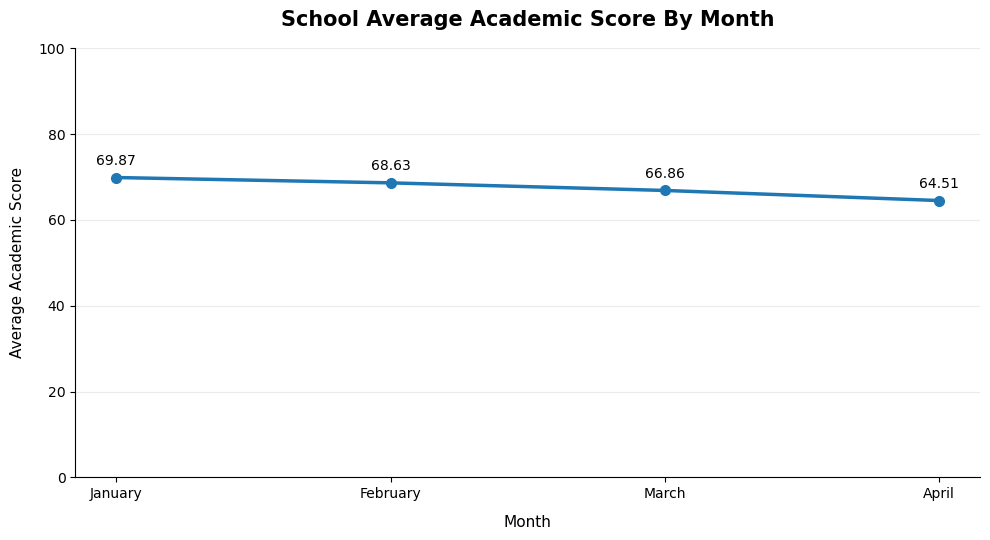

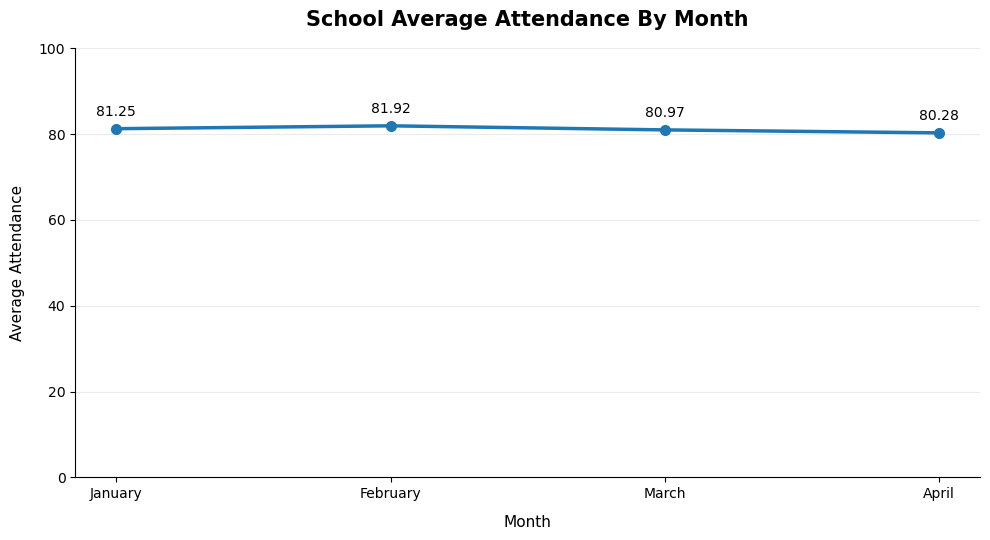

In [44]:
plot_directory = (
    export_directory
    / "Charts"
)

plot_directory.mkdir(
    parents=True,
    exist_ok=True,
)


def finish_chart(
    title,
    x_label,
    y_label,
    file_name,
    y_limits=None,
    grid_axis="y",
):
    axis = plt.gca()

    axis.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=16,
    )

    axis.set_xlabel(
        x_label,
        fontsize=11,
        labelpad=10,
    )

    axis.set_ylabel(
        y_label,
        fontsize=11,
        labelpad=10,
    )

    axis.tick_params(
        axis="both",
        labelsize=10,
    )

    axis.tick_params(
        axis="x",
        labelrotation=0,
    )

    axis.grid(
        axis=grid_axis,
        alpha=0.25,
    )

    axis.set_axisbelow(True)

    axis.spines[
        "top"
    ].set_visible(False)

    axis.spines[
        "right"
    ].set_visible(False)

    if y_limits is not None:
        axis.set_ylim(
            y_limits
        )

    plt.tight_layout()

    plt.savefig(
        plot_directory
        / file_name,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()


plt.figure(
    figsize=(10, 5.5)
)

plt.plot(
    monthly_school_summary[
        "month_name"
    ],
    monthly_school_summary[
        "average_academic_score"
    ],
    marker="o",
    linewidth=2.5,
    markersize=7,
)

for row in monthly_school_summary.itertuples(
    index=False
):
    plt.annotate(
        f"{row.average_academic_score:.2f}",
        (
            row.month_name,
            row.average_academic_score,
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=10,
    )

finish_chart(
    title=(
        "School Average Academic Score By Month"
    ),
    x_label="Month",
    y_label="Average Academic Score",
    file_name=(
        "Monthly Academic Performance.png"
    ),
    y_limits=(0, 100),
)


plt.figure(
    figsize=(10, 5.5)
)

plt.plot(
    monthly_school_summary[
        "month_name"
    ],
    monthly_school_summary[
        "average_attendance"
    ],
    marker="o",
    linewidth=2.5,
    markersize=7,
)

for row in monthly_school_summary.itertuples(
    index=False
):
    plt.annotate(
        f"{row.average_attendance:.2f}",
        (
            row.month_name,
            row.average_attendance,
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=10,
    )

finish_chart(
    title=(
        "School Average Attendance By Month"
    ),
    x_label="Month",
    y_label="Average Attendance",
    file_name=(
        "Monthly Attendance Performance.png"
    ),
    y_limits=(0, 100),
)

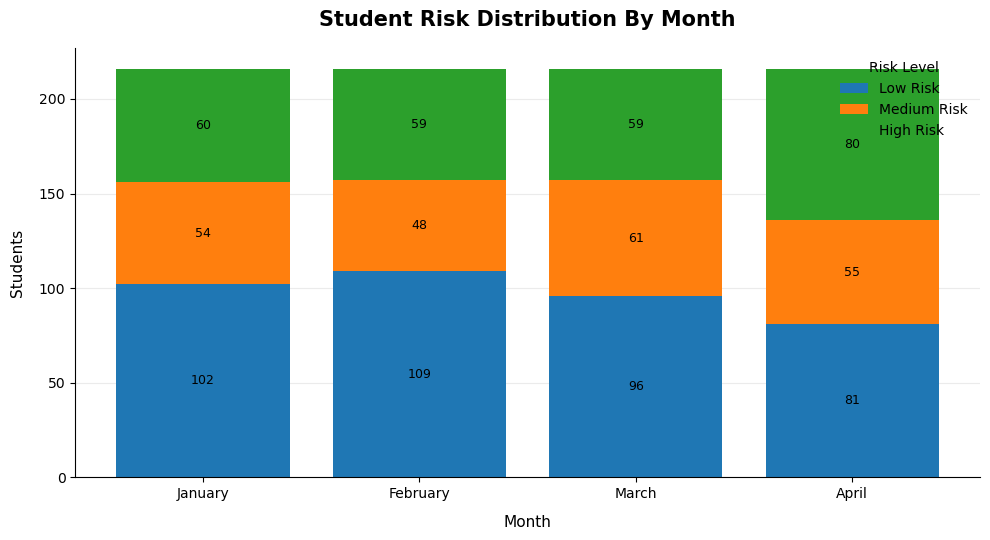

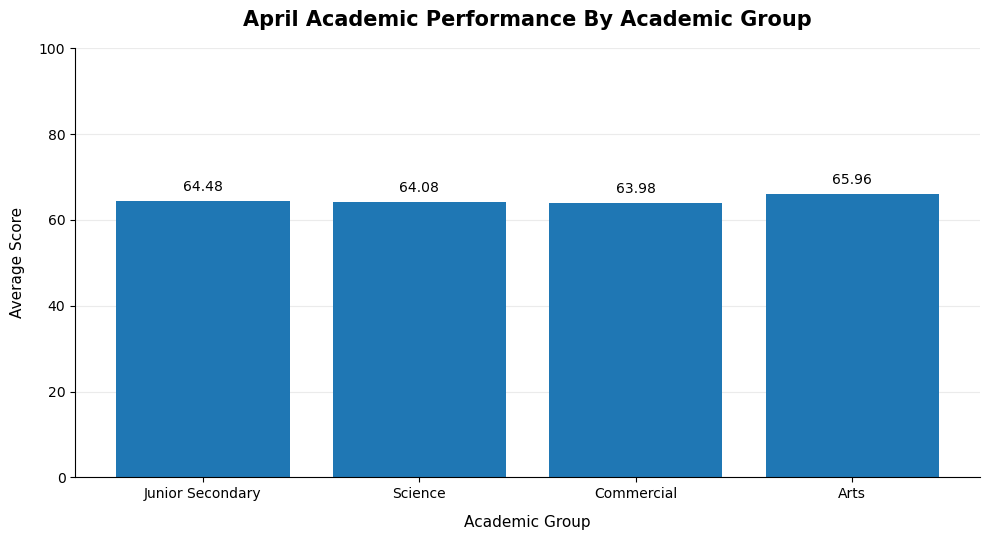

In [45]:
risk_chart_data = (
    monthly_school_summary.set_index(
        "month_name"
    )
    [
        [
            "low_risk_students",
            "medium_risk_students",
            "high_risk_students",
        ]
    ]
    .rename(
        columns={
            "low_risk_students": "Low Risk",
            "medium_risk_students": "Medium Risk",
            "high_risk_students": "High Risk",
        }
    )
)

months = risk_chart_data.index.tolist()
bottom_values = np.zeros(
    len(
        risk_chart_data
    )
)

plt.figure(
    figsize=(10, 5.5)
)

for risk_level in [
    "Low Risk",
    "Medium Risk",
    "High Risk",
]:
    values = risk_chart_data[
        risk_level
    ].to_numpy()

    bars = plt.bar(
        months,
        values,
        bottom=bottom_values,
        label=risk_level,
    )

    plt.bar_label(
        bars,
        labels=[
            str(
                int(value)
            )
            if value > 0
            else ""
            for value in values
        ],
        label_type="center",
        fontsize=9,
    )

    bottom_values = (
        bottom_values
        + values
    )

plt.legend(
    title="Risk Level",
    frameon=False,
)

finish_chart(
    title=(
        "Student Risk Distribution By Month"
    ),
    x_label="Month",
    y_label="Students",
    file_name=(
        "Monthly Risk Distribution.png"
    ),
)


academic_group_order = [
    "Junior Secondary",
    "Science",
    "Commercial",
    "Arts",
]

april_group_data = (
    stream_performance_summary[
        stream_performance_summary[
            "month_name"
        ] == "April"
    ]
    .copy()
)

april_group_data[
    "academic_stream"
] = pd.Categorical(
    april_group_data[
        "academic_stream"
    ],
    categories=academic_group_order,
    ordered=True,
)

april_group_data = (
    april_group_data.sort_values(
        "academic_stream"
    )
)

plt.figure(
    figsize=(10, 5.5)
)

bars = plt.bar(
    april_group_data[
        "academic_stream"
    ].astype(str),
    april_group_data[
        "average_score"
    ],
)

plt.bar_label(
    bars,
    fmt="%.2f",
    padding=5,
    fontsize=10,
)

finish_chart(
    title=(
        "April Academic Performance By Academic Group"
    ),
    x_label="Academic Group",
    y_label="Average Score",
    file_name=(
        "April Academic Group Performance.png"
    ),
    y_limits=(0, 100),
)

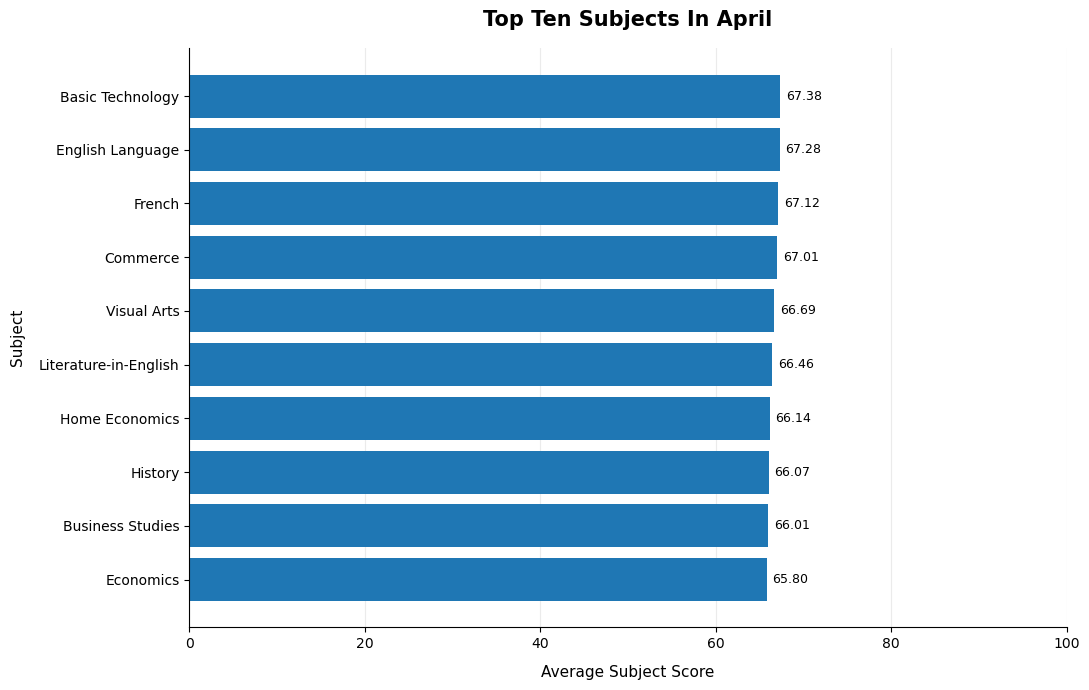

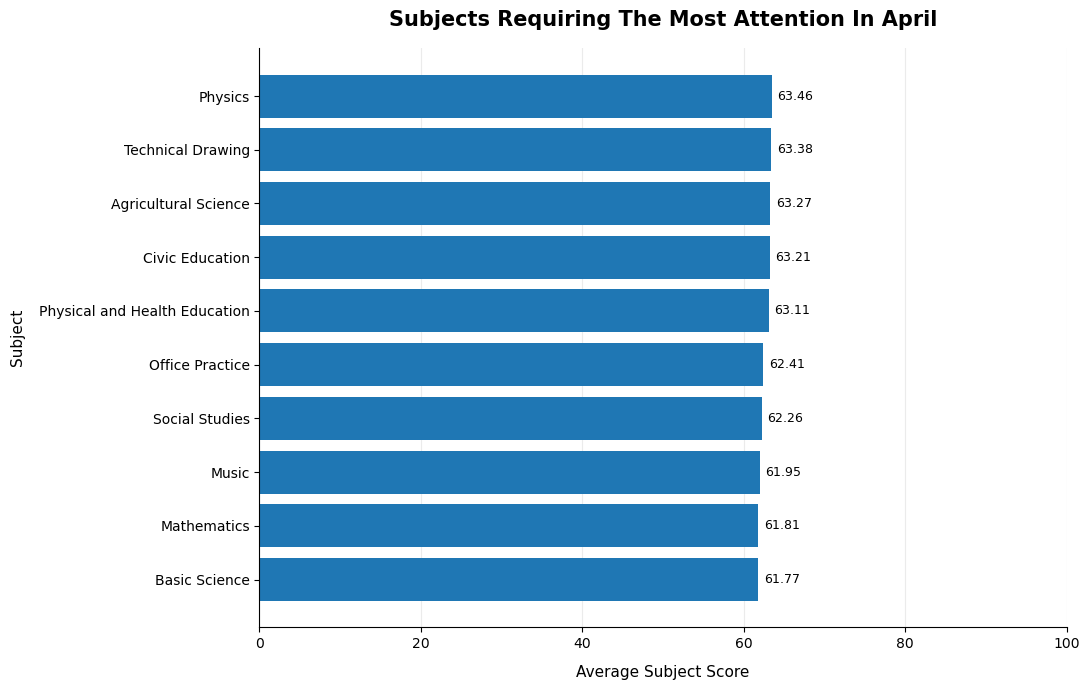

In [46]:
april_subject_data = (
    subject_performance_summary[
        subject_performance_summary[
            "month_name"
        ] == "April"
    ]
    .sort_values(
        "average_subject_score",
        ascending=False,
    )
)

top_subjects = (
    april_subject_data.head(
        10
    )
    .sort_values(
        "average_subject_score",
        ascending=True,
    )
)

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    top_subjects[
        "subject_name"
    ],
    top_subjects[
        "average_subject_score"
    ],
)

plt.bar_label(
    bars,
    fmt="%.2f",
    padding=4,
    fontsize=9,
)

plt.xlim(
    0,
    100,
)

finish_chart(
    title="Top Ten Subjects In April",
    x_label="Average Subject Score",
    y_label="Subject",
    file_name="Top Subjects In April.png",
    y_limits=None,
    grid_axis="x",
)


bottom_subjects = (
    april_subject_data.tail(
        10
    )
    .sort_values(
        "average_subject_score",
        ascending=True,
    )
)

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    bottom_subjects[
        "subject_name"
    ],
    bottom_subjects[
        "average_subject_score"
    ],
)

plt.bar_label(
    bars,
    fmt="%.2f",
    padding=4,
    fontsize=9,
)

plt.xlim(
    0,
    100,
)

finish_chart(
    title=(
        "Subjects Requiring The Most Attention In April"
    ),
    x_label="Average Subject Score",
    y_label="Subject",
    file_name=(
        "Subjects Requiring Attention In April.png"
    ),
    y_limits=None,
    grid_axis="x",
)

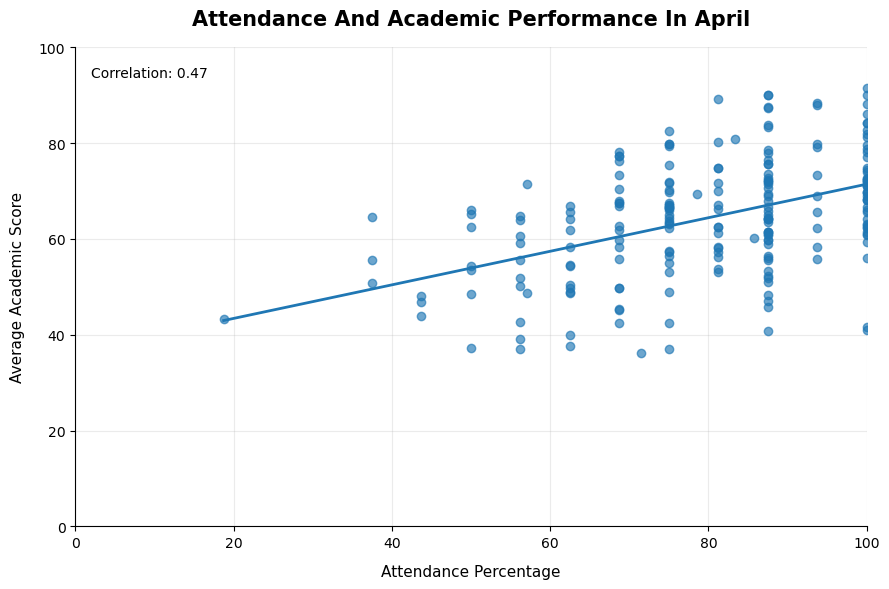

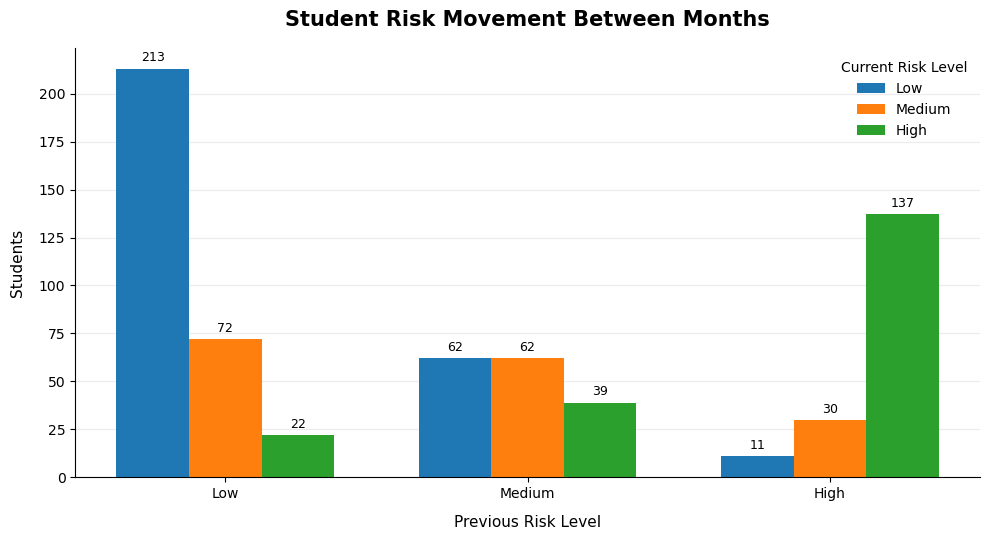

In [47]:
april_student_data = (
    student_monthly_analysis[
        student_monthly_analysis[
            "month_name"
        ] == "April"
    ]
    .copy()
)

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    april_student_data[
        "attendance_percentage"
    ],
    april_student_data[
        "average_score"
    ],
    alpha=0.65,
)

trend_values = np.polyfit(
    april_student_data[
        "attendance_percentage"
    ],
    april_student_data[
        "average_score"
    ],
    1,
)

trend_function = np.poly1d(
    trend_values
)

trend_x = np.linspace(
    april_student_data[
        "attendance_percentage"
    ].min(),
    april_student_data[
        "attendance_percentage"
    ].max(),
    100,
)

plt.plot(
    trend_x,
    trend_function(
        trend_x
    ),
    linewidth=2,
)

april_correlation = (
    april_student_data[
        [
            "attendance_percentage",
            "average_score",
        ]
    ]
    .corr()
    .iloc[
        0,
        1,
    ]
)

plt.text(
    0.02,
    0.96,
    (
        "Correlation: "
        + f"{april_correlation:.2f}"
    ),
    transform=plt.gca().transAxes,
    fontsize=10,
    va="top",
)

plt.xlim(
    0,
    100,
)

finish_chart(
    title=(
        "Attendance And Academic Performance In April"
    ),
    x_label="Attendance Percentage",
    y_label="Average Academic Score",
    file_name=(
        "Attendance And Academic Performance.png"
    ),
    y_limits=(0, 100),
    grid_axis="both",
)


transition_matrix = pd.crosstab(
    risk_transitions[
        "previous_risk_level"
    ],
    risk_transitions[
        "risk_level"
    ],
).reindex(
    index=[
        "Low",
        "Medium",
        "High",
    ],
    columns=[
        "Low",
        "Medium",
        "High",
    ],
    fill_value=0,
)

previous_levels = (
    transition_matrix.index.tolist()
)

current_levels = (
    transition_matrix.columns.tolist()
)

positions = np.arange(
    len(
        previous_levels
    )
)

bar_width = 0.24

plt.figure(
    figsize=(10, 5.5)
)

for level_number, current_level in enumerate(
    current_levels
):
    values = transition_matrix[
        current_level
    ].to_numpy()

    bars = plt.bar(
        positions
        + (
            level_number
            - 1
        )
        * bar_width,
        values,
        width=bar_width,
        label=current_level,
    )

    plt.bar_label(
        bars,
        labels=[
            str(
                int(value)
            )
            if value > 0
            else ""
            for value in values
        ],
        padding=3,
        fontsize=9,
    )

plt.xticks(
    positions,
    previous_levels,
    rotation=0,
)

plt.legend(
    title="Current Risk Level",
    frameon=False,
)

finish_chart(
    title=(
        "Student Risk Movement Between Months"
    ),
    x_label="Previous Risk Level",
    y_label="Students",
    file_name=(
        "Student Risk Movement Between Months.png"
    ),
)

In [48]:
monthly_summary_to_write = (
    student_monthly_analysis[
        [
            "monthly_summary_id",
            "enrollment_id",
            "month_name",
            "attendance_percentage",
            "average_score",
            "subjects_failed",
            "performance_change",
            "summary_status",
        ]
    ]
    .copy()
)

risk_profile_to_write = (
    student_monthly_analysis[
        [
            "risk_profile_id",
            "monthly_summary_id",
            "risk_level",
            "risk_score",
            "risk_reason",
            "recommended_action",
        ]
    ]
    .copy()
)

subject_risk_to_write = (
    student_subject_risk_analysis[
        [
            "subject_risk_id",
            "monthly_summary_id",
            "class_subject_id",
            "subject_average",
            "class_subject_average",
            "performance_gap",
            "risk_level",
            "risk_reason",
            "recommended_action",
        ]
    ]
    .copy()
)

export_dataframes = {
    "Student Monthly Analysis.csv": (
        student_monthly_analysis
    ),
    "Student Subject Risk Analysis.csv": (
        student_subject_risk_analysis
    ),
    "Monthly School Performance.csv": (
        monthly_school_summary
    ),
    "Class Performance Summary.csv": (
        class_performance_summary
    ),
    "Stream Performance Summary.csv": (
        stream_performance_summary
    ),
    "Subject Performance Summary.csv": (
        subject_performance_summary
    ),
    "Gender Performance Summary.csv": (
        gender_performance_summary
    ),
    "Risk Transition Summary.csv": (
        risk_transition_summary
    ),
    "Student Improvement Ranking.csv": (
        student_improvement_ranking
    ),
    "Attendance And Academic Correlation.csv": (
        correlation_summary
    ),
    "Student Intervention Queue.csv": (
        intervention_queue
    ),
    "DynamoDB Event Candidates.csv": (
        dynamodb_event_candidates
    ),
    "Data Quality Report.csv": (
        quality_report
    ),
}

for file_name, dataframe in export_dataframes.items():
    professional_data = professional_frame(
        dataframe
    )

    if any(
        "_" in column
        for column in professional_data.columns
    ):
        raise ValueError(
            "An Exported Column Contains An Underscore"
        )

    professional_data.to_csv(
        export_directory / file_name,
        index=False,
        encoding="utf-8",
    )

excel_path = (
    export_directory
    / "SchoolPulse Analytics Portfolio Outputs.xlsx"
)

excel_sheets = {
    "Monthly Performance": (
        student_monthly_analysis
    ),
    "Subject Risk": (
        student_subject_risk_analysis
    ),
    "School Summary": (
        monthly_school_summary
    ),
    "Class Summary": (
        class_performance_summary
    ),
    "Stream Summary": (
        stream_performance_summary
    ),
    "Subject Summary": (
        subject_performance_summary
    ),
    "Risk Transitions": (
        risk_transition_summary
    ),
    "Improvement Ranking": (
        student_improvement_ranking
    ),
    "Intervention Queue": (
        intervention_queue
    ),
    "Data Quality": (
        quality_report
    ),
}

try:
    with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
    ) as writer:
        for sheet_name, dataframe in excel_sheets.items():
            professional_frame(
                dataframe
            ).to_excel(
                writer,
                sheet_name=sheet_name,
                index=False,
            )

except ImportError:
    print(
        "Excel Export Was Skipped Because OpenPyXL "
        "Is Not Installed. All CSV Exports Were Completed."
    )

portfolio_summary = {
    "Students Analysed": int(
        student_monthly_analysis[
            "student_id"
        ].nunique()
    ),
    "Classes Analysed": int(
        student_monthly_analysis[
            "class_id"
        ].nunique()
    ),
    "Subjects Analysed": int(
        student_subject_risk_analysis[
            "subject_id"
        ].nunique()
    ),
    "Months Analysed": int(
        student_monthly_analysis[
            "month_name"
        ].nunique()
    ),
    "Monthly Student Records": int(
        len(
            student_monthly_analysis
        )
    ),
    "Subject Risk Records": int(
        len(
            student_subject_risk_analysis
        )
    ),
    "DynamoDB Event Candidates": int(
        len(
            dynamodb_event_candidates
        )
    ),
    "Data Quality Status": (
        "Passed"
        if failed_quality_checks.empty
        else "Requires Review"
    ),
}

with (
    export_directory
    / "Portfolio Summary.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        portfolio_summary,
        file,
        indent=4,
    )

print(
    "Portfolio Outputs Exported To "
    + str(
        export_directory.resolve()
    )
)

Portfolio Outputs Exported To <USER_HOME>\SchoolPulse Portfolio Outputs


In [49]:
if write_results_to_database:
    monthly_records = safe_records(
        monthly_summary_to_write
    )

    risk_records = safe_records(
        risk_profile_to_write
    )

    subject_risk_records = safe_records(
        subject_risk_to_write
    )

    cursor = connection.cursor()

    try:
        connection.commit()
        connection.start_transaction()

        cursor.execute(
            "DELETE FROM StudentSubjectRisk"
        )

        cursor.execute(
            "DELETE FROM StudentRiskProfile"
        )

        cursor.execute(
            "DELETE FROM StudentMonthlySummary"
        )

        cursor.executemany(
            '''
            INSERT INTO StudentMonthlySummary (
                MonthlySummaryID,
                EnrollmentID,
                MonthName,
                AttendancePercentage,
                AverageScore,
                SubjectsFailed,
                PerformanceChange,
                SummaryStatus
            )
            VALUES (
                %s, %s, %s, %s,
                %s, %s, %s, %s
            )
            ''',
            monthly_records,
        )

        cursor.executemany(
            '''
            INSERT INTO StudentRiskProfile (
                RiskProfileID,
                MonthlySummaryID,
                RiskLevel,
                RiskScore,
                RiskReason,
                RecommendedAction
            )
            VALUES (
                %s, %s, %s,
                %s, %s, %s
            )
            ''',
            risk_records,
        )

        cursor.executemany(
            '''
            INSERT INTO StudentSubjectRisk (
                SubjectRiskID,
                MonthlySummaryID,
                ClassSubjectID,
                SubjectAverage,
                ClassSubjectAverage,
                PerformanceGap,
                RiskLevel,
                RiskReason,
                RecommendedAction
            )
            VALUES (
                %s, %s, %s,
                %s, %s, %s,
                %s, %s, %s
            )
            ''',
            subject_risk_records,
        )

        connection.commit()

        print(
            "Database Analytics Tables Updated Successfully"
        )

    except Exception:
        connection.rollback()
        raise

    finally:
        cursor.close()

else:
    print(
        "Database Write Skipped"
    )

Database Analytics Tables Updated Successfully


In [50]:
saved_table_validation = read_query(
    '''
    SELECT
        'Monthly Summaries' AS CheckName,
        COUNT(*) AS ActualValue,
        864 AS ExpectedValue
    FROM StudentMonthlySummary

    UNION ALL

    SELECT
        'Overall Risk Profiles',
        COUNT(*),
        864
    FROM StudentRiskProfile

    UNION ALL

    SELECT
        'Subject Risk Records',
        COUNT(*),
        11328
    FROM StudentSubjectRisk
    '''
)

saved_table_validation[
    "validation_status"
] = np.where(
    saved_table_validation[
        "actual_value"
    ]
    == saved_table_validation[
        "expected_value"
    ],
    "PASS",
    "CHECK",
)

show_table(
    "Saved Database Analytics Validation",
    saved_table_validation,
    rows=len(
        saved_table_validation
    ),
)

connection.close()

print("Python Analytics Pipeline Completed")

,Check Name,Actual Value,Expected Value,Validation Status
0,Monthly Summaries,864,864,PASS
1,Overall Risk Profiles,864,864,PASS
2,Subject Risk Records,11328,11328,PASS


Python Analytics Pipeline Completed
